# [LAB 04] 11. 이상치 처리

## #01. 준비작업

### 1. 패키지 설치

- 상자 그림을 위해 `matplotlib` 패키지의 설치가 필요하다.

In [1]:
!pip install --upgrade matplotlib

### 2. 라이브러리 참조

In [2]:
import numpy as np
from jussam import load_data
from pandas import DataFrame
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 3. 데이터 가져오기

In [3]:
origin = load_data("ref_sample")
origin

📚 데이터 정제를 위한 실습용 데이터


,kor,eng,math,sic
name,,,,
철수,98.000,77,88.000,64.000
영희,88.000,120,62.000,72.000
민철,NaN,70,83.000,79.000
수현,63.000,60,31.000,71.000
호영,75.000,50,90.000,NaN
영호,80.000,88,91.000,72.000
용식,82.000,88,NaN,90.000
나영,90.000,92,81.000,NaN
석영,91.000,90,89.000,80.000


## #02. 결측치 정제하기

### 1. 결측치를 평균으로 대체

In [4]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(origin.values)
re_df = DataFrame(df_imr, index=origin.index, columns=origin.columns)
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,120.000,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #03. 이상치가 존재하는 변수 찾기

### 1. 상자그림 확인하기

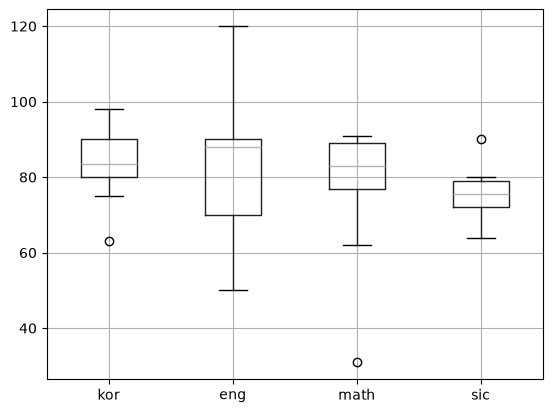

In [5]:
re_df.boxplot()
plt.show()

> 국어, 수학, 영어에 이상치가 있음이 확인된다.

## #04. 분석가의 주관에 따른 이상치 판별

- 점수가 아무리 낮더라도 정상 점수 범위(`0~100`)라면 답안지를 밀려 썼거나 시험중 실수가 발생했을 수 있다.
  - 이 경우 정상적인 시험 결과로 간주하는 것이 옳다고 판단.
- 정상 점수 범위(`0~100`)를 벗어난 경우라면 채점에 오류가 있을 수 있다고 판단하여 이상치로 판별해야 한다.

### 1. 이상치를 결측치로 변경

In [6]:
re_df.loc[re_df['eng'] > 100, 'eng'] = np.nan
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,NaN,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 2. 변경된 결측치에 대한 처리

In [7]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(re_df.values)
outline_df = DataFrame(df_imr, index=re_df.index, columns=re_df.columns)
outline_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #05. 극단치 경계값을 계산하여 이상치 찾기

### 1. 사분위간 범위 계산

In [8]:
outline_df2 = outline_df.copy()
국어Q1 = outline_df2['kor'].quantile(0.25)
국어Q3 = outline_df2['kor'].quantile(0.75)
국어iqr = 국어Q3 - 국어Q1
print("국어 점수의 사분위간 범위:", 국어iqr)

국어 점수의 사분위간 범위: 10.0


### 2. 극단치 경계값 찾기

| 구분 | 수식 |
|---|---|
| 상한 극단치 경계 | $상한 = Q_3 + iqr * 1.5$ |
| 하한 극단치 경계 | $하한 = Q_1 - iqr * 1.5$ |

In [9]:
outline_max = 국어Q3 + 국어iqr * 1.5
outline_min = 국어Q1 - 국어iqr * 1.5
print("상한 극단치 경계:", outline_max)
print("하한 극단치 경계:", outline_min)

상한 극단치 경계: 105.0
하한 극단치 경계: 65.0


### 3. 극단치 경계값을 활용하여 국어 점수에 대한 하한 이상치 확인

In [10]:
outline_df2.loc[outline_df2['kor'] < outline_min, 'kor']

name
수현   63.000
Name: kor, dtype: float64

### 4. 국어 점수에 대한 하한 이상치를 결측치로 변환

In [11]:
outline_df2.loc[outline_df['kor'] < outline_min, 'kor'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 5. 국어 점수에 대한 상한 이상치를 검색하여 결측치로 변환

In [12]:
outline_df2.loc[outline_df2['kor'] > outline_max, 'kor'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 6. 수학 점수의 극단치 경계값을 활용한 이상치 처리

- 상자그림으로 확인했을 때, 영어에 대한 이상치는 없었으므로 수학과 과학에 대해서만 처리한다.

In [13]:
수학Q1 = outline_df2['math'].quantile(0.25)
수학Q3 = outline_df2['math'].quantile(0.75)
수학iqr = 수학Q3 - 수학Q1
outline_max = 수학Q3 + 수학iqr * 1.5
outline_min = 수학Q1 - 수학iqr * 1.5

outline_df2.loc[outline_df2['math'] < outline_min, 'math'] = np.nan
outline_df2.loc[outline_df2['math'] > outline_max, 'math'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 7. 과학 점수의 극단치 경계값을 활용한 이상치 처리

In [14]:
과학Q1 = outline_df2['sic'].quantile(0.25)
과학Q3 = outline_df2['sic'].quantile(0.75)
과학iqr = 과학Q3 - 과학Q1
outline_max = 과학Q3 + 과학iqr * 1.5
outline_min = 과학Q1 - 과학iqr * 1.5

outline_df2.loc[outline_df2['sic'] < outline_min, 'sic'] = np.nan
outline_df2.loc[outline_df2['sic'] > outline_max, 'sic'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,NaN
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### 8. 마지막 단계: 결측치로 변환된 값을 처리한다.

In [15]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(outline_df2.values)
final_df = DataFrame(df_imr, index=outline_df2.index,
                     columns=outline_df2.columns)
final_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,85.922,60.000,82.609,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,73.607
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


## #06. 이상치를 이상치 경계값으로 대체하기 (모든 컬럼 일괄처리)

In [16]:
# 분석가 주관에 의한 이상치 정제 데이터에서 이어서 진행
outline_df3 = outline_df.copy()

# 컬럼만큼 반복
for c in outline_df3.columns:
    # 사분위 구간 계산
    Q1 = outline_df3[c].quantile(0.25)
    Q3 = outline_df3[c].quantile(0.75)
    iqr = Q3 - Q1

    # 이상치 경계 계산
    outline_min = Q1 - iqr * 1.5
    outline_max = Q3 + iqr * 1.5

    # 이상치 정제
    outline_df3.loc[outline_df3[c] < outline_min, c] = outline_min
    outline_df3.loc[outline_df3[c] > outline_max, c] = outline_max

outline_df3

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,65.000,60.000,58.688,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,89.500
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000
